=== İyileştirilmiş Random Forest (Threshold=0.35) ===
              precision    recall  f1-score   support

    Negative       0.96      0.86      0.91       938
    Positive       0.49      0.81      0.61       158

    accuracy                           0.85      1096
   macro avg       0.73      0.84      0.76      1096
weighted avg       0.90      0.85      0.87      1096



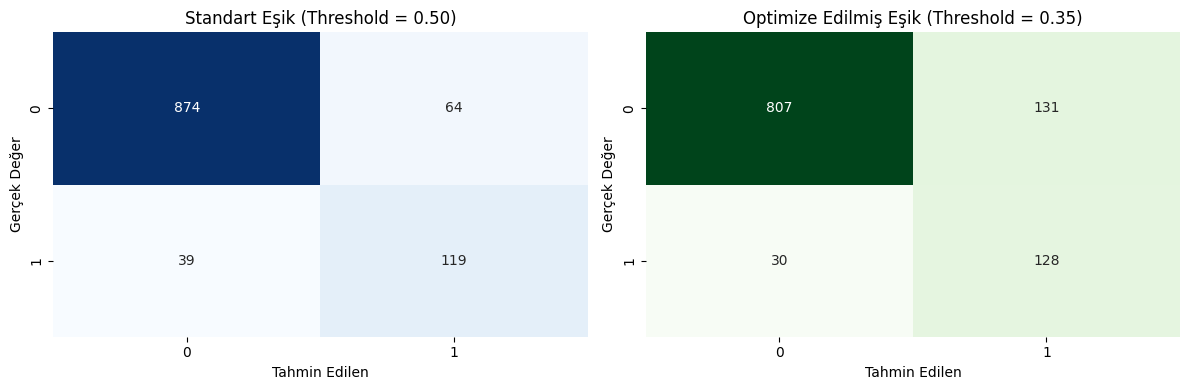

In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

os.makedirs("/content/results/figures", exist_ok=True)

# 1. Veri Yükle
df = pd.read_csv("/content/Spellman_with_labels.csv")
orf_col = df.columns[0]
time_cols = [col for col in df.columns if col not in [orf_col, 'label']]

X_raw = df[time_cols].values
y = df['label'].values

# 2. Özellik Çıkarımı (İstatistik + FFT + Autocorr)
def extract_features(X):
    features = {}
    features['mean'] = np.mean(X, axis=1)
    features['std'] = np.std(X, axis=1)
    features['max'] = np.max(X, axis=1)
    features['min'] = np.min(X, axis=1)
    features['range'] = features['max'] - features['min']

    fft_vals = np.abs(np.fft.fft(X, axis=1))
    n = X.shape[1]
    features['fft_power_low'] = np.sum(fft_vals[:, 1:5], axis=1)
    features['fft_power_mid'] = np.sum(fft_vals[:, 5:12], axis=1)
    features['fft_power_total'] = np.sum(fft_vals[:, 1:n//2], axis=1)
    features['dominant_freq'] = np.argmax(fft_vals[:, 1:n//2], axis=1)

    def autocorr(x):
        result = np.correlate(x - np.mean(x), x - np.mean(x), mode='full')
        return result[result.size//2:] / (np.std(x)**2 * len(x))

    ac = np.array([autocorr(row) for row in X])
    features['autocorr_lag1'] = ac[:, 1]
    features['autocorr_lag2'] = ac[:, 2] if ac.shape[1] > 2 else np.zeros(len(X))
    return pd.DataFrame(features)

X = extract_features(X_raw)

# 3. Train/Test & SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# 4. Model Eğitimi
rf = RandomForestClassifier(
    n_estimators=500, max_depth=12, min_samples_leaf=2,
    class_weight='balanced_subsample', random_state=42, n_jobs=-1
)
rf.fit(X_train_bal, y_train_bal)

y_pred_proba = rf.predict_proba(X_test)[:, 1]
y_pred_default = (y_pred_proba >= 0.50).astype(int)
y_pred_thresh = (y_pred_proba >= 0.35).astype(int)

print("=== İyileştirilmiş Random Forest (Threshold=0.35) ===")
print(classification_report(y_test, y_pred_thresh, target_names=['Negative', 'Positive']))

# ====================== GÖRSELLEŞTİRME ======================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_default = confusion_matrix(y_test, y_pred_default)
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title("Standart Eşik (Threshold = 0.50)")
axes[0].set_xlabel("Tahmin Edilen")
axes[0].set_ylabel("Gerçek Değer")

cm_thresh = confusion_matrix(y_test, y_pred_thresh)
sns.heatmap(cm_thresh, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title("Optimize Edilmiş Eşik (Threshold = 0.35)")
axes[1].set_xlabel("Tahmin Edilen")
axes[1].set_ylabel("Gerçek Değer")

plt.tight_layout()
plt.savefig("/content/results/figures/rf_threshold_comparison.png", dpi=300)
plt.show()